In [ ]:

Lab Assignments

In [4]:
pip install nltk

Note: you may need to restart the kernel to use updated packages.


In [2]:
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:

SET A

In [ ]:
1. Consider any text paragraph. Preprocess the text to remove any special characters and digits. Generate
the summary using extractive summarization process.

In [3]:
import re
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords
from collections import defaultdict

text = """
Machine learning is a branch of artificial intelligence that enables computers 
to learn from data and improve their performance without being explicitly programmed. 
It is widely used in applications such as image recognition, speech processing, 
recommendation systems, and autonomous vehicles. 
Despite its advantages, machine learning faces challenges such as data privacy, 
bias in algorithms, and high computational costs. 
Researchers continue to develop new techniques to make machine learning models 
more efficient, accurate, and reliable.
"""

clean_text = re.sub(r'[^a-zA-Z\s]', '', text).lower()

words = word_tokenize(clean_text)
stop_words = set(stopwords.words('english'))
filtered_words = [w for w in words if w not in stop_words]

word_freq = defaultdict(int)
for w in filtered_words:
    word_freq[w] += 1

sentences = sent_tokenize(text)
sentence_scores = {}

for sentence in sentences:
    for word in word_tokenize(sentence.lower()):
        if word in word_freq:
            sentence_scores[sentence] = sentence_scores.get(sentence, 0) + word_freq[word]

top_sentences = sorted(sentence_scores, key=sentence_scores.get, reverse=True)[:2]
summary = [s for s in sentences if s in top_sentences]

print("Summary:\n")
print(" ".join(summary))


Summary:


Machine learning is a branch of artificial intelligence that enables computers 
to learn from data and improve their performance without being explicitly programmed. Despite its advantages, machine learning faces challenges such as data privacy, 
bias in algorithms, and high computational costs.


In [ ]:
2. Consider any text paragraph. Remove the stopwords. Tokenize the paragraph to extract words and
sentences. Calculate the word frequency distribution and plot the frequencies. Plot the wordcloud of
the text

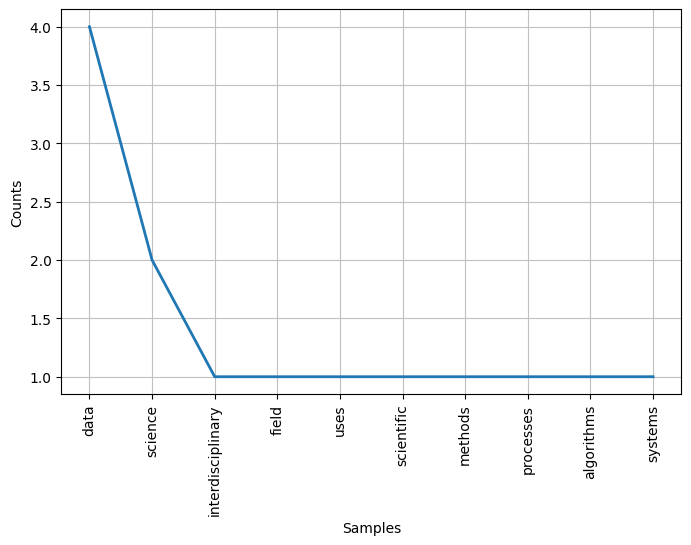

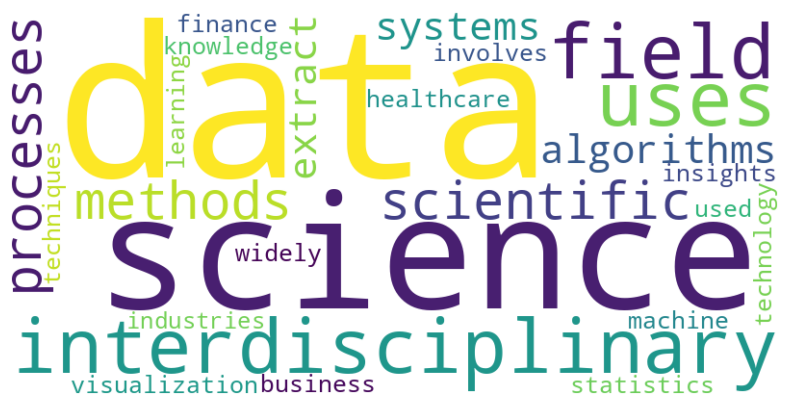

In [5]:
import nltk
import matplotlib.pyplot as plt
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.probability import FreqDist
from wordcloud import WordCloud

text = """
Data science is an interdisciplinary field that uses scientific methods, 
processes, algorithms, and systems to extract knowledge and insights from data. 
It involves statistics, machine learning, and data visualization techniques. 
Data science is widely used in business, healthcare, finance, and technology industries.
"""

sentences = sent_tokenize(text)
words = word_tokenize(text.lower())

stop_words = set(stopwords.words('english'))
filtered_words = [w for w in words if w.isalpha() and w not in stop_words]

freq_dist = FreqDist(filtered_words)

plt.figure(figsize=(8,5))
freq_dist.plot(10)
plt.show()

wordcloud = WordCloud(width=800, height=400, background_color='white') \
            .generate(" ".join(filtered_words))

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()


In [ ]:
3. Consider the following review messages. Perform sentiment analysis on the messages.
i. I purchased headphones online. I am very happy with the product.
ii. I saw the movie yesterday. The animation was really good but the script was ok.
iii. I enjoy listening to music
iv. I take a walk in the park everyday


In [7]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk


reviews = [
    "I purchased headphones online. I am very happy with the product.",
    "I saw the movie yesterday. The animation was really good but the script was ok.",
    "I enjoy listening to music",
    "I take a walk in the park everyday"
]

sentiment_analyzer = SentimentIntensityAnalyzer()

for i, review in enumerate(reviews, 1):
    polarity = sentiment_analyzer.polarity_scores(review)
    compound = polarity['compound']
    if compound >= 0.05:
        sentiment = "Positive"
    elif compound <= -0.05:
        sentiment = "Negative"
    else:
        sentiment = "Neutral"
    print(f"Review {i}: {review}")
    print(f"Sentiment: {sentiment}, Scores: {polarity}\n")


Review 1: I purchased headphones online. I am very happy with the product.
Sentiment: Positive, Scores: {'neg': 0.0, 'neu': 0.667, 'pos': 0.333, 'compound': 0.6115}

Review 2: I saw the movie yesterday. The animation was really good but the script was ok.
Sentiment: Positive, Scores: {'neg': 0.0, 'neu': 0.71, 'pos': 0.29, 'compound': 0.5989}

Review 3: I enjoy listening to music
Sentiment: Positive, Scores: {'neg': 0.0, 'neu': 0.484, 'pos': 0.516, 'compound': 0.4939}

Review 4: I take a walk in the park everyday
Sentiment: Neutral, Scores: {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}



In [ ]:
4. Perform text analytics on WhatsApp data :
Write a Python script for the following :
i. First Export the WhatsApp chat of any group. Read the exported “.txt” file using open() and read()
functions.
ii. Tokenize the read data into sentences and print it.
iii. Remove the stopwords from data and perform lemmatization.
iv. Plot the wordcloud for the given data

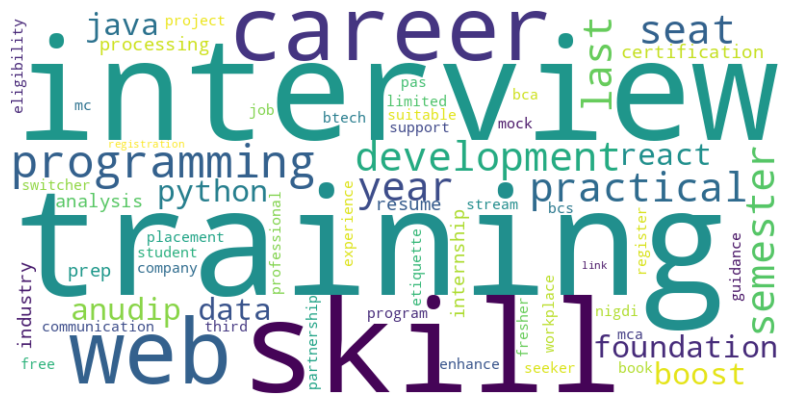

In [10]:
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
import matplotlib.pyplot as plt

file_path = "whatsapp.txt"
with open(file_path, "r", encoding="utf-8") as file:
    chat_data = file.read()

sentences = sent_tokenize(chat_data)

words = word_tokenize(chat_data.lower())
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

filtered_words = [lemmatizer.lemmatize(w) for w in words if w.isalpha() and w not in stop_words]

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(" ".join(filtered_words))

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.show()


In [ ]:
SET B

In [ ]:
1. Consider the following dataset :
    https://www.kaggle.com/datasets/prasertk/top-1000-instagram-influencers
Write a Python script for the following :
i. Read the dataset and find the top 5 Instagram influencers from India.
ii. Find the Instagram account having least number of followers.
iii. Read the column “Category”, remove stopwords and plot the wordcloud to find the keywords which
    will imply that in which category maximum accounts are created.
iv. Group the Instagram accounts category wise.
v. Visualize the dataset and plot the relationship between Followers and Authentic engagement columns.

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud

df = pd.read_csv("top_1000_instagrammers.csv")

df

,Name,Rank,Category,Followers,Audience Country,Authentic Engagement,Engagement Avg.
0,cristiano,1,Sports with a ball,462.9M,India,5.5M,6.6M
1,leomessi,2,Sports with a ballFamily,347.2M,Argentina,3.6M,4.8M
2,kendalljenner,3,ModelingFashion,247.6M,United States,3M,4.9M
3,arianagrande,4,Music,321.4M,United States,2.4M,3.4M
4,zendaya,5,Cinema & Actors/actressesFashion,147M,United States,4.3M,5.8M
...,...,...,...,...,...,...,...
995,nimratkhairaofficial,996,Music,8M,India,211.1K,261.8K
996,hanhyojoo222,997,TravelCinema & Actors/actresses,4M,Indonesia,434.2K,518.2K
997,memphisdepay,998,Sports with a ball,15M,France,76.4K,135.5K
998,arminzareeiofficial,999,NaN,9.8M,Iran,135.4K,214K


In [25]:
top5_india = df[df["Audience Country"] == "India"].sort_values(by="Followers", ascending=False).head(5)
print("Top 5 Influencers from India:\n", top5_india[["Name", "Followers"]])



Top 5 Influencers from India:
                   Name Followers
637          jaspritb1      9.8M
680            djsnake      9.6M
101            yawnzzn      9.6M
627            djsnake      9.5M
628  kareenakapoorkhan      9.4M


In [16]:
least_followers = df.sort_values(by="Followers", ascending=True).iloc[0]
print("\nInstagram account with least followers:\n", least_followers[["Name", "Followers"]])




Instagram account with least followers:
 Name         la_beaute_africaine
Followers                   1.6M
Name: 772, dtype: object


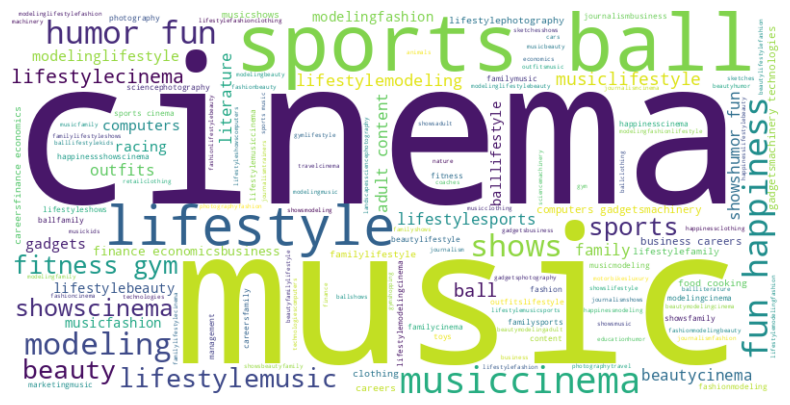

In [17]:
categories = df["Category"].dropna().str.lower().tolist()
stop_words = set(stopwords.words("english"))
all_words = []

for cat in categories:
    for w in word_tokenize(cat):
        if w.isalpha() and w not in stop_words:
            all_words.append(w)

wc = WordCloud(width=800, height=400, background_color="white").generate(" ".join(all_words))
plt.figure(figsize=(10,5))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.show()



In [18]:
grouped = df.groupby("Category").size()
print("\nAccounts grouped by category:\n", grouped)




Accounts grouped by category:
 Category
Adult content                                6
Animals                                      1
Art/Artists                                  7
Art/ArtistsBeauty                            1
Art/ArtistsCinema & Actors/actresses         1
                                            ..
Sports with a ballLifestyle                  4
Sports with a ballLifestyleKids & Toys       1
Sports with a ballLiterature & Journalism    1
Sports with a ballShows                      1
TravelCinema & Actors/actresses              1
Length: 153, dtype: int64


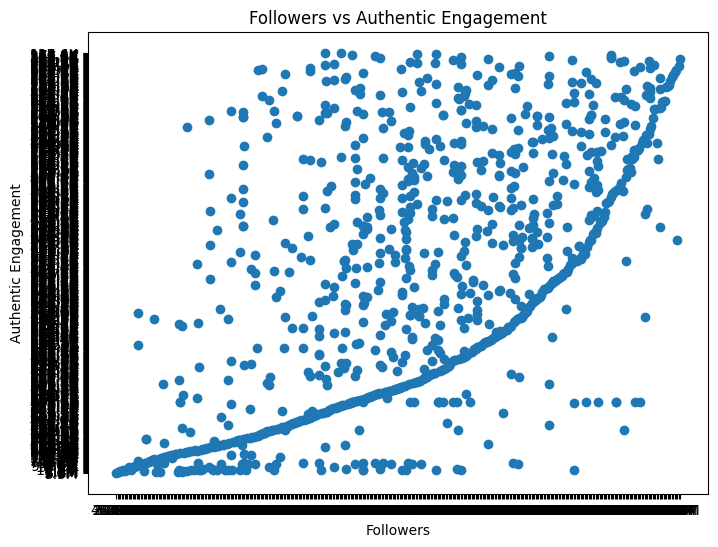

In [21]:
plt.figure(figsize=(8,6))
plt.scatter(df["Followers"], df["Authentic Engagement"])
plt.xlabel("Followers")
plt.ylabel("Authentic Engagement")
plt.title("Followers vs Authentic Engagement")
plt.show()


In [ ]:
2. Consider the following dataset :
    https://www.kaggle.com/datasets/seungguini/youtube-comments-for-covid19-related-
    videos?select=covid_2021_1.csv
Write a Python script for the following :
i. Read the dataset and perform data cleaning operations on it.
ii. Tokenize the comments in words.
iii. Perform sentiment analysis and find the percentage of positive, negative and neutral comments.

In [1]:
import pandas as pd
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.sentiment.vader import SentimentIntensityAnalyzer

df = pd.read_csv("covid_2021_1.csv")
df



,query,url,title,upload_date,channel,views,likes,dislikes,comment_count,comment_text,comment_author,comment_date,comment_likes,DATE
0,coronavirus|covid%7C19|pandemic|vaccine,https://www.youtube.com/watch?v=LyRoIKjmk9o,Which Coronavirus Vaccine Is More Effective? C...,2021-01-01T09:04:16Z,India Today,8276,58,7,5,OMG 😍💋 💝💖❤️,Brendan Eric,2021-01-01T09:23:59Z,0,2021-01-01 09:04:16+00:00
1,coronavirus|covid%7C19|pandemic|vaccine,https://www.youtube.com/watch?v=LyRoIKjmk9o,Which Coronavirus Vaccine Is More Effective? C...,2021-01-01T09:04:16Z,India Today,8276,58,7,5,I love my Indian Mumbai me welcome,Bhallesingh Rathore rathore,2021-01-01T09:06:51Z,1,2021-01-01 09:04:16+00:00
2,coronavirus|covid%7C19|pandemic|vaccine,https://www.youtube.com/watch?v=LyRoIKjmk9o,Which Coronavirus Vaccine Is More Effective? C...,2021-01-01T09:04:16Z,India Today,8276,58,7,5,What about indian vaccine?,Kudip singh hong kong.,2021-02-03T08:17:14Z,0,2021-01-01 09:04:16+00:00
3,coronavirus|covid%7C19|pandemic|vaccine,https://www.youtube.com/watch?v=LyRoIKjmk9o,Which Coronavirus Vaccine Is More Effective? C...,2021-01-01T09:04:16Z,India Today,8276,58,7,5,2:32 I like that😍💋 💝💖❤️,Bo Brice,2021-01-01T09:55:34Z,0,2021-01-01 09:04:16+00:00
4,coronavirus|covid%7C19|pandemic|vaccine,https://www.youtube.com/watch?v=dwMWM1F7NMI,Growing Number Of Americans Going Hungry Durin...,2021-01-01T11:59:49Z,NBC News,74546,874,62,601,And all the rich companies that have profited ...,Poppy Jalto,2021-01-01T13:17:56Z,93,2021-01-01 11:59:49+00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41583,coronavirus|covid%7C19|pandemic|vaccine,https://www.youtube.com/watch?v=nBFln3cAnUk,War Against Corona Virus |Coronavirudh Mahayud...,2021-01-30T04:27:07Z,Rachana’s NavAngel World,26087,1140,47,91,Thanks da,Urmila Vichare,2021-01-30T05:04:34Z,1,2021-01-30 04:27:07+00:00
41584,coronavirus|covid%7C19|pandemic|vaccine,https://www.youtube.com/watch?v=nBFln3cAnUk,War Against Corona Virus |Coronavirudh Mahayud...,2021-01-30T04:27:07Z,Rachana’s NavAngel World,26087,1140,47,91,👍👍 very helpful information,Bhagya and Mumma,2021-01-31T05:39:23Z,2,2021-01-30 04:27:07+00:00
41585,coronavirus|covid%7C19|pandemic|vaccine,https://www.youtube.com/watch?v=nBFln3cAnUk,War Against Corona Virus |Coronavirudh Mahayud...,2021-01-30T04:27:07Z,Rachana’s NavAngel World,26087,1140,47,91,👍,Rushali Bakarekar,2021-02-01T08:50:00Z,1,2021-01-30 04:27:07+00:00
41586,coronavirus|covid%7C19|pandemic|vaccine,https://www.youtube.com/watch?v=nBFln3cAnUk,War Against Corona Virus |Coronavirudh Mahayud...,2021-01-30T04:27:07Z,Rachana’s NavAngel World,26087,1140,47,91,Very very much informative vlog..Sunny da ne v...,Madhuri Sonavane,2021-01-30T04:45:07Z,1,2021-01-30 04:27:07+00:00


In [5]:
df = df.dropna(subset=['comment_text'])
df['Comment'] = df['comment_text'].str.lower().str.replace(r'[^a-z\s]', '', regex=True)
df['Comment']



0                                                    omg  
1                       i love my indian mumbai me welcome
2                                what about indian vaccine
3                                             i like that 
4        and all the rich companies that have profited ...
                               ...                        
41583                                            thanks da
41584                             very helpful information
41585                                                     
41586    very very much informative vlogsunny da ne vac...
41587                    thanking you for this information
Name: Comment, Length: 41588, dtype: object

In [7]:
words = df['Comment'].apply(word_tokenize)

stop_words = set(stopwords.words('english'))
filtered_words = words.apply(lambda ws: [w for w in ws if w not in stop_words])
filtered_words

0                                                    [omg]
1                          [love, indian, mumbai, welcome]
2                                        [indian, vaccine]
3                                                   [like]
4                       [rich, companies, profited, covid]
                               ...                        
41583                                         [thanks, da]
41584                               [helpful, information]
41585                                                   []
41586    [much, informative, vlogsunny, da, ne, vaccine...
41587                              [thanking, information]
Name: Comment, Length: 41588, dtype: object

In [9]:
sid = SentimentIntensityAnalyzer()

sentiments = df['Comment'].apply(lambda c: sid.polarity_scores(c)['compound'])

positive = sum(sentiments >= 0.05)
negative = sum(sentiments <= -0.05)
neutral = len(sentiments) - positive - negative

total = len(sentiments)
print("Positive %:", positive*100/total)
print("Negative %:", negative*100/total)
print("Neutral %:", neutral*100/total)

Positive %: 40.43954987015485
Negative %: 25.235644897566605
Neutral %: 34.32480523227854


In [ ]:
3 Consider the following dataset :
https://www.kaggle.com/datasets/datasnaek/youtube-new?select=INvideos.csv
Write a Python script for the following :
i. Read the dataset and perform data cleaning operations on it.
ii. Find the total views, total likes, total dislikes and comment count.
iii. Find the least and topmost liked and commented videos.
iv. Perform year wise statistics for views and plot the analyzed data.
v. Plot the viewers who reacted on videos

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("INvideos.csv")
df


,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description
0,kzwfHumJyYc,17.14.11,Sharry Mann: Cute Munda ( Song Teaser) | Parmi...,Lokdhun Punjabi,1,2017-11-12T12:20:39.000Z,"sharry mann|""sharry mann new song""|""sharry man...",1096327,33966,798,882,https://i.ytimg.com/vi/kzwfHumJyYc/default.jpg,False,False,False,Presenting Sharry Mann latest Punjabi Song Cu...
1,10L1hZ9qa58,17.14.11,Stylish Star Allu Arjun @ ChaySam Wedding Rece...,TFPC,24,2017-11-12T15:48:08.000Z,Stylish Star Allu Arjun @ ChaySam Wedding Rece...,473988,2011,243,149,https://i.ytimg.com/vi/10L1hZ9qa58/default.jpg,False,False,False,Watch Stylish Star Allu Arjun @ ChaySam Weddin...
2,N1vE8iiEg64,17.14.11,Eruma Saani | Tamil vs English,Eruma Saani,23,2017-11-12T07:08:48.000Z,"Eruma Saani|""Tamil Comedy Videos""|""Films""|""Mov...",1242680,70353,1624,2684,https://i.ytimg.com/vi/N1vE8iiEg64/default.jpg,False,False,False,This video showcases the difference between pe...
3,kJzGH0PVQHQ,17.14.11,why Samantha became EMOTIONAL @ Samantha naga ...,Filmylooks,24,2017-11-13T01:14:16.000Z,"Filmylooks|""latest news""|""telugu movies""|""telu...",464015,492,293,66,https://i.ytimg.com/vi/kJzGH0PVQHQ/default.jpg,False,False,False,why Samantha became EMOTIONAL @ Samantha naga ...
4,il_pSa5l98w,17.14.11,"MCA (Middle Class Abbayi) TEASER - Nani,Sai Pa...",Dil Raju,24,2017-11-10T04:29:50.000Z,"Nenu Local|""Nenu Local Telugu Movie""|""Nani""|""S...",6106669,98612,4185,4763,https://i.ytimg.com/vi/il_pSa5l98w/default.jpg,False,False,False,Watch MCA- Middle Class Abbayi First Look Teas...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37346,iNHecA3PJCo,18.14.06,फेकू आशिक़ - राजस्थान की सबसे शानदार कॉमेडी | ...,RDC Rajasthani,23,2018-06-13T08:01:11.000Z,"twinkle vaishnav comedy|""twinkle vaishnav""|""tw...",214378,3291,404,196,https://i.ytimg.com/vi/iNHecA3PJCo/default.jpg,False,False,False,PRG Music & RDC Rajasthani presents फेकू आशिक़...
37347,dpPmPbhcslM,18.14.06,Seetha | Flowers | Ep# 364,Flowers TV,24,2018-06-13T11:30:04.000Z,"flowers serials|""actress""|""malayalam serials""|...",406828,1726,478,1428,https://i.ytimg.com/vi/dpPmPbhcslM/default.jpg,False,False,False,"Flowers - A R Rahman Show,Book your Tickets He..."
37348,mV6aztP58f8,18.14.06,Bhramanam I Episode 87 - 12 June 2018 I Mazhav...,Mazhavil Manorama,24,2018-06-13T05:00:02.000Z,"mazhavil manorama|""bhramanam full episode""|""gt...",386319,1216,453,697,https://i.ytimg.com/vi/mV6aztP58f8/default.jpg,False,False,False,Subscribe to Mazhavil Manorama now for your da...
37349,qxqDNP1bDEw,18.14.06,Nua Bohu | Full Ep 285 | 13th June 2018 | Odia...,Tarang TV,24,2018-06-13T15:07:49.000Z,"tarang|""tarang tv""|""tarang tv online""|""tarang ...",130263,698,115,65,https://i.ytimg.com/vi/qxqDNP1bDEw/default.jpg,False,False,False,Nuabohu : Story of a rustic village girl who w...


In [13]:
df["views"] = pd.to_numeric(df["views"], errors="coerce")
df["likes"] = pd.to_numeric(df["likes"], errors="coerce")
df["dislikes"] = pd.to_numeric(df["dislikes"], errors="coerce")
df["comment_count"] = pd.to_numeric(df["comment_count"], errors="coerce")

df


,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description
0,kzwfHumJyYc,17.14.11,Sharry Mann: Cute Munda ( Song Teaser) | Parmi...,Lokdhun Punjabi,1,2017-11-12T12:20:39.000Z,"sharry mann|""sharry mann new song""|""sharry man...",1096327,33966,798,882,https://i.ytimg.com/vi/kzwfHumJyYc/default.jpg,False,False,False,Presenting Sharry Mann latest Punjabi Song Cu...
1,zUZ1z7FwLc8,17.14.11,"पीरियड्स के समय, पेट पर पति करता ऐसा, देखकर दं...",HJ NEWS,25,2017-11-13T05:43:56.000Z,"पीरियड्स के समय|""पेट पर पति करता ऐसा""|""देखकर द...",590101,735,904,0,https://i.ytimg.com/vi/zUZ1z7FwLc8/default.jpg,True,False,False,"पीरियड्स के समय, पेट पर पति करता ऐसा, देखकर दं..."
2,10L1hZ9qa58,17.14.11,Stylish Star Allu Arjun @ ChaySam Wedding Rece...,TFPC,24,2017-11-12T15:48:08.000Z,Stylish Star Allu Arjun @ ChaySam Wedding Rece...,473988,2011,243,149,https://i.ytimg.com/vi/10L1hZ9qa58/default.jpg,False,False,False,Watch Stylish Star Allu Arjun @ ChaySam Weddin...
3,N1vE8iiEg64,17.14.11,Eruma Saani | Tamil vs English,Eruma Saani,23,2017-11-12T07:08:48.000Z,"Eruma Saani|""Tamil Comedy Videos""|""Films""|""Mov...",1242680,70353,1624,2684,https://i.ytimg.com/vi/N1vE8iiEg64/default.jpg,False,False,False,This video showcases the difference between pe...
4,kJzGH0PVQHQ,17.14.11,why Samantha became EMOTIONAL @ Samantha naga ...,Filmylooks,24,2017-11-13T01:14:16.000Z,"Filmylooks|""latest news""|""telugu movies""|""telu...",464015,492,293,66,https://i.ytimg.com/vi/kJzGH0PVQHQ/default.jpg,False,False,False,why Samantha became EMOTIONAL @ Samantha naga ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37347,iNHecA3PJCo,18.14.06,फेकू आशिक़ - राजस्थान की सबसे शानदार कॉमेडी | ...,RDC Rajasthani,23,2018-06-13T08:01:11.000Z,"twinkle vaishnav comedy|""twinkle vaishnav""|""tw...",214378,3291,404,196,https://i.ytimg.com/vi/iNHecA3PJCo/default.jpg,False,False,False,PRG Music & RDC Rajasthani presents फेकू आशिक़...
37348,dpPmPbhcslM,18.14.06,Seetha | Flowers | Ep# 364,Flowers TV,24,2018-06-13T11:30:04.000Z,"flowers serials|""actress""|""malayalam serials""|...",406828,1726,478,1428,https://i.ytimg.com/vi/dpPmPbhcslM/default.jpg,False,False,False,"Flowers - A R Rahman Show,Book your Tickets He..."
37349,mV6aztP58f8,18.14.06,Bhramanam I Episode 87 - 12 June 2018 I Mazhav...,Mazhavil Manorama,24,2018-06-13T05:00:02.000Z,"mazhavil manorama|""bhramanam full episode""|""gt...",386319,1216,453,697,https://i.ytimg.com/vi/mV6aztP58f8/default.jpg,False,False,False,Subscribe to Mazhavil Manorama now for your da...
37350,qxqDNP1bDEw,18.14.06,Nua Bohu | Full Ep 285 | 13th June 2018 | Odia...,Tarang TV,24,2018-06-13T15:07:49.000Z,"tarang|""tarang tv""|""tarang tv online""|""tarang ...",130263,698,115,65,https://i.ytimg.com/vi/qxqDNP1bDEw/default.jpg,False,False,False,Nuabohu : Story of a rustic village girl who w...


In [12]:
total_views = df["views"].sum()
total_likes = df["likes"].sum()
total_dislikes = df["dislikes"].sum()
total_comments = df["comment_count"].sum()

print("Total Views:", total_views)
print("Total Likes:", total_likes)
print("Total Dislikes:", total_dislikes)
print("Total Comment Count:", total_comments)






Total Views: 39610961029
Total Likes: 1011593670
Total Dislikes: 62194142
Total Comment Count: 99991208


In [14]:
max_liked = df.loc[df["likes"].idxmax()]
min_liked = df.loc[df["likes"].idxmin()]

max_commented = df.loc[df["comment_count"].idxmax()]
min_commented = df.loc[df["comment_count"].idxmin()]

print("\nTopmost Liked Video:\n", max_liked[["title", "likes"]])
print("\nLeast Liked Video:\n", min_liked[["title", "likes"]])
print("\nTopmost Commented Video:\n", max_commented[["title", "comment_count"]])
print("\nLeast Commented Video:\n", min_commented[["title", "comment_count"]])


Topmost Liked Video:
 title    YouTube Rewind: The Shape of 2017 | #YouTubeRe...
likes                                              2912710
Name: 5408, dtype: object

Least Liked Video:
 title    Breaking News IT Raid - நடந்தது என்ன? சிக்கியத...
likes                                                    0
Name: 34, dtype: object

Topmost Commented Video:
 title            YouTube Rewind: The Shape of 2017 | #YouTubeRe...
comment_count                                               827755
Name: 4743, dtype: object

Least Commented Video:
 title            पीरियड्स के समय, पेट पर पति करता ऐसा, देखकर दं...
comment_count                                                    0
Name: 1, dtype: object


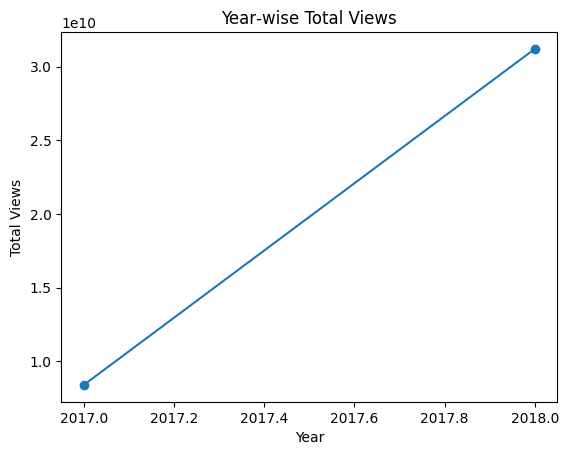

In [15]:
df["publish_time"] = pd.to_datetime(df["publish_time"], errors="coerce")
df["year"] = df["publish_time"].dt.year

yearly = df.groupby("year")["views"].sum().reset_index()
plt.plot(yearly["year"], yearly["views"], marker="o")
plt.title("Year‑wise Total Views")
plt.xlabel("Year")
plt.ylabel("Total Views")
plt.show()


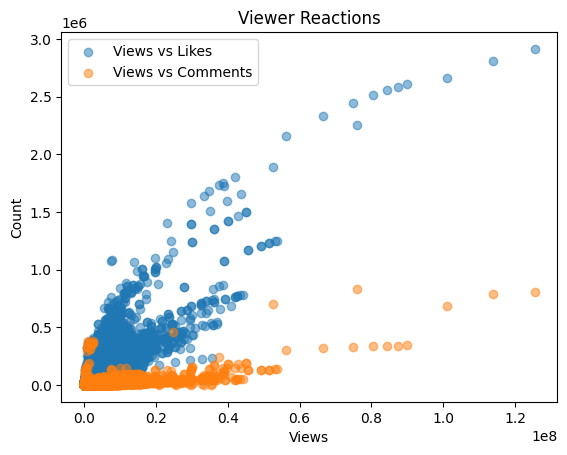

In [16]:
plt.scatter(df["views"], df["likes"], alpha=0.5, label="Views vs Likes")
plt.scatter(df["views"], df["comment_count"], alpha=0.5, label="Views vs Comments")
plt.legend()
plt.xlabel("Views")
plt.ylabel("Count")
plt.title("Viewer Reactions")
plt.show()
